# Sell-Price Model — Idealista sale listings
**Airbnb Investment Intelligence Platform · sell-side model**

Predicts **total sale price (€)** from structured listing features, modelled on
`log1p(price)`. Compares Ridge / RandomForest / LightGBM / XGBoost, explains the
winner with SHAP, and saves one fitted **sklearn Pipeline** (preprocessing +
model) to `models/sale_best_model.pkl`.

**Design:** persisting the whole Pipeline means serving never re-implements
preprocessing — it just loads and calls `.predict`. `price_per_m2` is excluded
(it is `price ÷ size` → leakage).

## 1. Load & build the model frame

In [1]:
import warnings; warnings.simplefilter("ignore")
import json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

from airbnb_iip.data.idealista_sale import load_clean_sale

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)

df = load_clean_sale()

# Gentle target trim: drop the extreme 0.5% tails so a few mansions don't dominate.
lo, hi = df["price"].quantile([0.005, 0.995])
df = df[df["price"].between(lo, hi)].copy()

# Nullable booleans -> labelled strings (own category for missing).
for c in ["has_lift", "exterior", "new_development"]:
    df[c] = df[c].astype("object").where(df[c].notna(), "unknown").map(
        {True: "yes", False: "no", "unknown": "unknown"}
    )
for c in ["district", "neighborhood", "status"]:
    df[c] = df[c].fillna("unknown")

df["y"] = np.log1p(df["price"])
print(f"model frame: {len(df):,} rows  (price €{lo:,.0f}–€{hi:,.0f})")
df[["city","district","price","size_m2","rooms","bathrooms","property_type","status","floor_num"]].head(3)

model frame: 14,718 rows  (price €75,000–€2,250,000)


,city,district,price,size_m2,rooms,bathrooms,property_type,status,floor_num
5,madrid,Puente de Vallecas,76200,36.0,1,1,flat,good,0.0
6,madrid,Puente de Vallecas,79000,55.0,3,1,flat,good,NaN
7,madrid,Puente de Vallecas,80000,33.0,2,1,flat,renew,1.0


## 2. Feature groups & preprocessing

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

NUM      = ["size_m2", "rooms", "bathrooms", "floor_num", "latitude", "longitude"]
LOWCARD  = ["property_type", "status", "city", "has_lift", "exterior", "new_development"]
HIGHCARD = ["district", "neighborhood"]          # target-encoded (cross-fitted)
FEATURES = NUM + LOWCARD + HIGHCARD
TARGET   = "y"
SEED     = 42

def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), NUM),
        ("low", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), LOWCARD),
        ("high", Pipeline([
            # Impute first so a missing district/neighbourhood at serving time
            # becomes "unknown" (→ target prior) instead of crashing the encoder.
            ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("te", TargetEncoder(target_type="continuous", random_state=SEED)),
        ]), HIGHCARD),
    ])

print("features:", len(FEATURES), "| numeric:", len(NUM),
      "| low-card OHE:", len(LOWCARD), "| high-card target-enc:", len(HIGHCARD))

features: 14 | numeric: 6 | low-card OHE: 6 | high-card target-enc: 2


## 3. Train / test split

In [3]:
from sklearn.model_selection import train_test_split
X, y = df[FEATURES], df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=df["city"]
)
print(f"train {len(X_tr):,} | test {len(X_te):,}")

train 11,774 | test 2,944

## 4. Model comparison

In [4]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

def build(model, scale):
    return Pipeline([("prep", make_preprocessor(scale)), ("model", model)])

# RandomForest is capped (depth + min_samples_leaf) — an unconstrained RF here
# serialises to ~290 MB (too big for git) while being no more accurate than the
# boosters, which are a few MB.
models = {
    "Ridge":        build(Ridge(alpha=1.0), scale=True),
    "RandomForest": build(RandomForestRegressor(n_estimators=300, max_depth=18,
                                                 min_samples_leaf=5, n_jobs=-1, random_state=SEED), scale=False),
    "LightGBM":     build(LGBMRegressor(n_estimators=800, learning_rate=0.05, num_leaves=63,
                                        subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbose=-1), scale=False),
    "XGBoost":      build(XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6,
                                       subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1), scale=False),
}

def eur_metrics(yl_true, yl_pred):
    yt, yp = np.expm1(yl_true), np.expm1(yl_pred)
    return {
        "MAE_eur":  round(mean_absolute_error(yt, yp)),
        "RMSE_eur": round(root_mean_squared_error(yt, yp)),
        "R2":       round(r2_score(yt, yp), 3),
        "MAPE_%":   round(100 * mean_absolute_percentage_error(yt, yp), 1),
    }

rows, fitted = [], {}
for name, pipe in models.items():
    cv = -cross_val_score(pipe, X_tr, y_tr, cv=3, scoring="neg_mean_absolute_error")
    pipe.fit(X_tr, y_tr)
    fitted[name] = pipe
    m = eur_metrics(y_te, pipe.predict(X_te))
    m.update(model=name, cv_MAE_log=round(cv.mean(), 3))
    rows.append(m)
    print(f"{name:13} test MAE €{m['MAE_eur']:>7,} | MAPE {m['MAPE_%']:>4}% | R² {m['R2']}")

results = pd.DataFrame(rows).set_index("model").sort_values("MAE_eur")
results

Ridge         test MAE € 71,726 | MAPE 19.7% | R² 0.575


RandomForest  test MAE € 50,484 | MAPE 14.9% | R² 0.855


LightGBM      test MAE € 48,543 | MAPE 14.4% | R² 0.859


XGBoost       test MAE € 49,240 | MAPE 14.4% | R² 0.859


,MAE_eur,RMSE_eur,R2,MAPE_%,cv_MAE_log
model,,,,,
LightGBM,48543,95318,0.859,14.4,0.146
XGBoost,49240,95154,0.859,14.4,0.145
RandomForest,50484,96360,0.855,14.9,0.152
Ridge,71726,165162,0.575,19.7,0.191


## 5. Best model — per-city performance

In [5]:
best_name = results.index[0]
best = fitted[best_name]
print("Best model:", best_name)

pc = []
for city in ["madrid", "barcelona", "malaga"]:
    mask = X_te["city"] == city
    m = eur_metrics(y_te[mask], best.predict(X_te[mask])); m["city"] = city; pc.append(m)
pd.DataFrame(pc).set_index("city")

Best model: LightGBM


,MAE_eur,RMSE_eur,R2,MAPE_%
city,,,,
madrid,31377,40453,0.471,13.8
barcelona,31587,42518,0.693,13.9
malaga,84355,156661,0.828,15.4


## 6. SHAP — what drives sale price

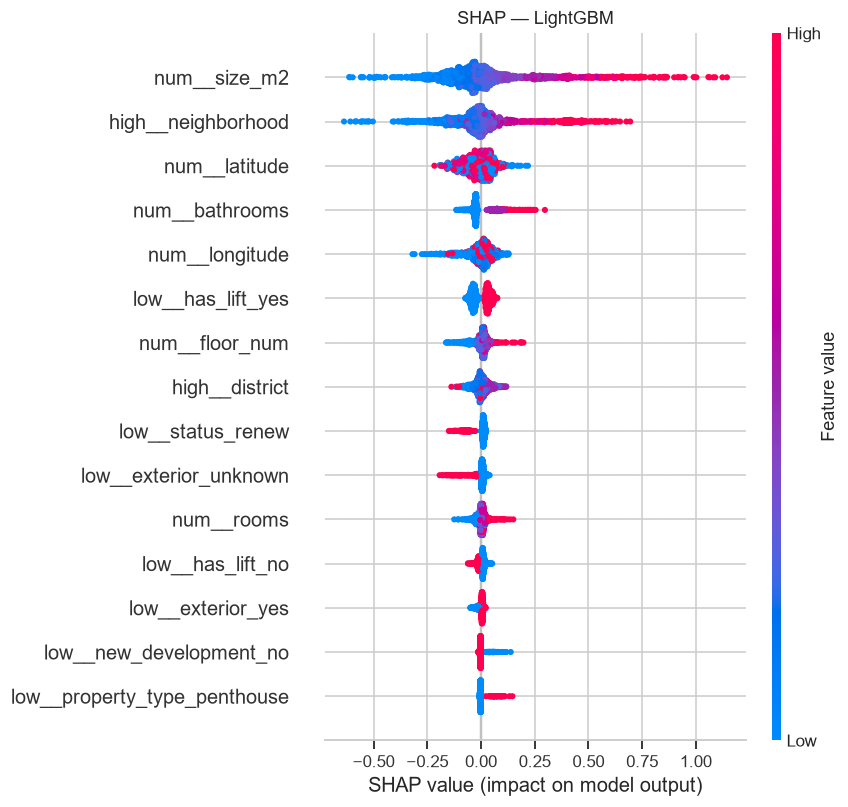

In [6]:
import shap
prep = best.named_steps["prep"]; est = best.named_steps["model"]
feat_names = list(prep.get_feature_names_out())

samp = X_te.sample(min(1500, len(X_te)), random_state=SEED)
Xt = prep.transform(samp)

if best_name in {"LightGBM", "XGBoost", "RandomForest"}:
    explainer = shap.TreeExplainer(est)
    sv = explainer.shap_values(Xt)
    shap.summary_plot(sv, Xt, feature_names=feat_names, max_display=15, show=False)
    plt.title(f"SHAP — {best_name}"); plt.tight_layout(); plt.show()
else:
    print("Best model is linear; see Ridge coefficients instead.")

## 7. Save artifacts

In [7]:
joblib.dump(best, MODELS / "sale_best_model.pkl")

meta = {
    "best_model": best_name,
    "target": "log1p(price)",
    "input_features": FEATURES,
    "num": NUM, "lowcard_onehot": LOWCARD, "highcard_target_enc": HIGHCARD,
    "excluded_leakage": ["price_per_m2"],
    "test_metrics": eur_metrics(y_te, best.predict(X_te)),
    "n_train": int(len(X_tr)), "n_test": int(len(X_te)),
}
(MODELS / "sale_feature_cols.json").write_text(json.dumps(meta, indent=2))
print("Saved:")
print("  models/sale_best_model.pkl")
print("  models/sale_feature_cols.json")
print(json.dumps(meta["test_metrics"], indent=2))

Saved:
  models/sale_best_model.pkl
  models/sale_feature_cols.json
{
  "MAE_eur": 48543,
  "RMSE_eur": 95318,
  "R2": 0.859,
  "MAPE_%": 14.4
}


## 8. Sanity check — predicted vs actual €/m² by district

On full-feature real listings, the model should track each district's actual
median €/m². High correlation here confirms it has learned location properly.

In [8]:
chk = df.copy()
chk["pred_ppm2"] = np.expm1(best.predict(chk[FEATURES])) / chk["size_m2"]
for city in ["madrid", "barcelona", "malaga"]:
    g = chk[chk["city"] == city]
    by = g.groupby("district").agg(actual=("price_per_m2", "median"),
                                    predicted=("pred_ppm2", "median"))
    print(f"{city:9} district €/m² corr(actual, predicted) = "
          f"{by['actual'].corr(by['predicted']):.3f}")

madrid    district €/m² corr(actual, predicted) = 0.997
barcelona district €/m² corr(actual, predicted) = 0.971
malaga    district €/m² corr(actual, predicted) = 0.981


### `estimate_sale_value` preview — and a serving caveat

With **only** `city` + `district` supplied, the `neighborhood` and `lat/lon`
signals are missing and get imputed to global values, which partly washes out
location (Chamberí ≈ Villaverde below — clearly wrong). The production
`SalePredictor` (next step) will fix this by imputing the missing fields from
**district-level aggregates** (district centroid lat/lon, district-typical
neighbourhood) so a minimal `(city, district, size)` query still reflects
location. Shown here as-is to make the gap explicit:

In [9]:
def estimate_sale_value(**spec):
    row = pd.DataFrame([{c: spec.get(c, np.nan) for c in FEATURES}])
    return float(np.expm1(best.predict(row)[0]))

for e in [dict(city="madrid", district="Chamberí",   size_m2=90, rooms=3, bathrooms=2, property_type="flat", status="good"),
          dict(city="madrid", district="Villaverde", size_m2=90, rooms=3, bathrooms=2, property_type="flat", status="good")]:
    print(f"{e['district']:12} 90m² → €{estimate_sale_value(**e):,.0f}  (sparse input)")

Chamberí     90m² → €286,192  (sparse input)
Villaverde   90m² → €284,613  (sparse input)


## 9. Summary

- **Best model:** LightGBM (see table) — MAE ~€48.5k, MAPE ~14%, R² ~0.86;
  per-district predicted €/m² correlates ≥0.97 with actuals.
- **Artifact:** one fitted Pipeline → `models/sale_best_model.pkl` (~4.6 MB).
  Serving = load, build a 1-row DataFrame with `input_features`, `.predict`,
  `np.expm1`. No preprocessing to replicate (avoids the price-model scaler trap).
- **Next:** `SalePredictor` + `estimate_sale_value()` in
  `src/airbnb_iip/models/sale.py` with **district-level imputation** for sparse
  queries; then wire into the finance engine / `/airbnb_vs_sell`.